# Exercises for Chapter 19, Causal inference using regression on the treatment variable

In [18]:
import os
import sys

import numpy

from matplotlib import pyplot

sys.path.append(os.path.abspath("/home/bgawalt/ros"))
import bg_ros

In [19]:
prng_builder = bg_ros.PRNGBuilder('Exercises for Chapter 19, Causal inference using regression on the treatment variable')

## 19.4, Pre-test and post-test

> 100 students are given a pre-test, then a treatment or control is randomly
> assigned to each, then they get a post-test.  Given the following regression
> model:
>
> $$\text{post\_test} = a + b \cdot \text{pre\_test} + \theta \cdot z + \text{error},$$
>
> where $z = 1$ for treated units and 0 for controls.  Further suppose that
> `pre_test` has mean 40 and standard deviation 15.  Suppose $b = 0.7$ and
> $\theta = 10$ and the mean for `post_test` is 50 for the students in the
> control group. Further suppose that the residual standard deviation of the 
> regression is 10.
>
> (a) Determine a.
>
> (b) What is the standard deviation of the post-test scores for the students in
>     the control group?
>
> (c) What are the mean and standard deviation of the post-test scores in the
>     treatment group?

In [20]:
# E[post] = a + b E[pre]
a = 50 - (0.7 * 40)
sd_y0 = 0.7 * 15 + 10
mu_y1 = a + (0.7 * 40) + 10
print(f'a = {a:0.2f}')
print(f'sd_y0 = {sd_y0:0.2f}')
print(f'mu_y1 = {mu_y1:0.2f}')

a = 22.00
sd_y0 = 20.50
mu_y1 = 60.00


## 19.6, Sketching the regression model for causal inference

> Assume that linear regression is appropriate for the regression of an outcome,
> $y$, on treatment indicator, $z$, and a single confounding covariate, $x$.
> With pen on paper, sketch hypothetical data (plotting $y$ versus $x$, with
> treated and control units indicated by circles and dots, respectively) and
> regression lines (for treatment and control group) that represent each of the
> following situations:
>
> (a) No treatment effect,
> 
> (b) Constant treatment effect,
>
> (c) Treatment effect increasing with $x$.

In [21]:
rng = prng_builder.new('19.6, Sketching the regression model for causal inference')

In [22]:
def fake_series(
    rng: numpy.random.Generator,
    constant_effect: float = 0,
    covariate_effect: float = 0
) -> (numpy.ndarray, numpy.ndarray):
    n = 40
    xs = rng.uniform(low=0, high=10, size=n)
    ys = 20 + constant_effect + (-3 + covariate_effect) * xs + rng.normal(scale=2, size=n)
    return (xs, ys)

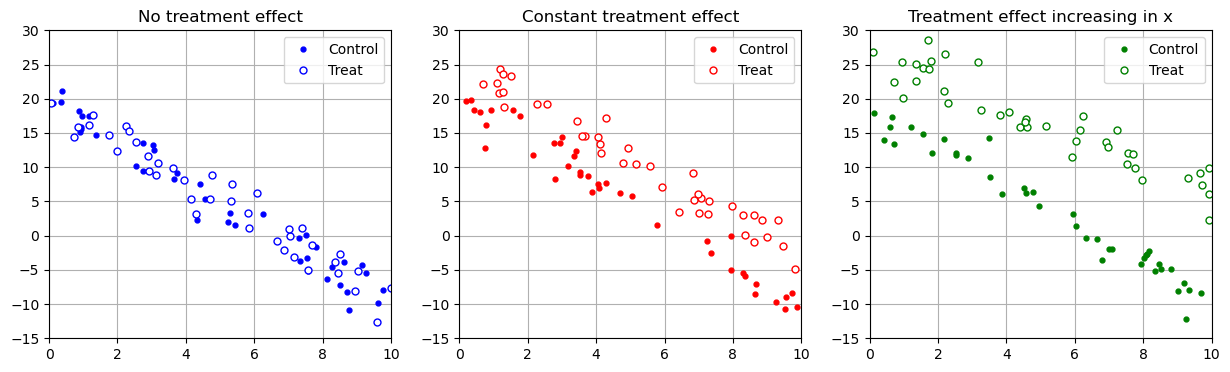

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

<Figure size 500x400 with 0 Axes>

In [23]:
fig, axs = pyplot.subplots(nrows=1, ncols=3, figsize=(15, 4))

x_c, y_c = fake_series(rng)
x_t, y_t = fake_series(rng)
fig = pyplot.figure(figsize=(5, 4))
ax = axs[0]
ax.set_title('No treatment effect')
color = 'b'

ax.plot(x_c, y_c, mec=color, mfc=color, linewidth=0, marker='.', markersize=7, label='Control')
ax.plot(x_t, y_t, mec=color, mfc='w', linewidth=0, marker='o', markersize=5, label='Treat')
ax.grid()
ax.set_axisbelow(True)
ax.set_ylim(-15, 30)
ax.set_xlim(0, 10)
ax.legend()

x_c, y_c = fake_series(rng)
x_t, y_t = fake_series(rng, constant_effect=6)
fig = pyplot.figure(figsize=(5, 4))
ax = axs[1]
ax.set_title('Constant treatment effect')
color = 'r'

ax.plot(x_c, y_c, mec=color, mfc=color, linewidth=0, marker='.', markersize=7, label='Control')
ax.plot(x_t, y_t, mec=color, mfc='w', linewidth=0, marker='o', markersize=5, label='Treat')
ax.grid()
ax.set_axisbelow(True)
ax.set_ylim(-15, 30)
ax.set_xlim(0, 10)
ax.legend()

x_c, y_c = fake_series(rng)
x_t, y_t = fake_series(rng, constant_effect=6, covariate_effect=1)
fig = pyplot.figure(figsize=(5, 4))
ax = axs[2]
ax.set_title('Treatment effect increasing in x')
color = 'g'

ax.plot(x_c, y_c, mec=color, mfc=color, linewidth=0, marker='.', markersize=7, label='Control')
ax.plot(x_t, y_t, mec=color, mfc='w', linewidth=0, marker='o', markersize=5, label='Treat')
ax.grid()
ax.set_axisbelow(True)
ax.set_ylim(-15, 30)
ax.set_xlim(0, 10)
ax.legend()